In [74]:
%display latex

## Quelques exemples de courbes

In [75]:
def trace_courbe(f,a,b):
    '''
    Entrées :
    f : courbe définie implicitement par f SOUS LA FORME D'UNE FONCTION
    a : demi-taille de la fenêtre sur l'axe des abscisses
    b : demi-taille de la fenêtre sur l'axe des ordonnées
    Sortie :
    Tracé de la courbe f(x,y) = 0 sur la fenêtre [-a, a] x [-b, b]
    '''
    x, y = var('x, y')
    return implicit_plot(f,(x,-a,a),(y,-b,b))

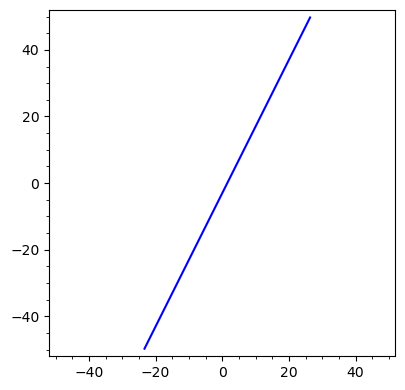

In [76]:
#Droite
d = lambda x, y:y-2*x+3
trace_courbe(d,50,50)

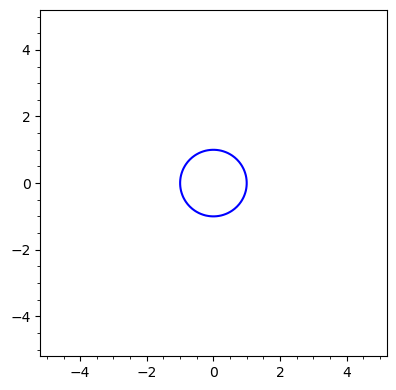

In [77]:
#Cercle
C = lambda x, y:x^2+y^2-1
trace_courbe(C,5,5)

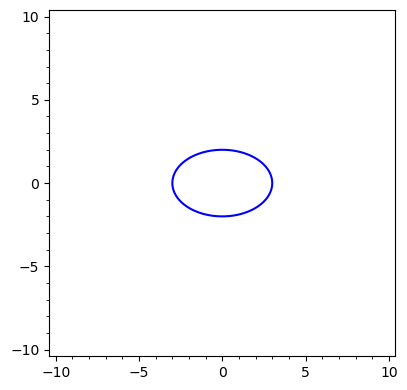

In [78]:
#Ellipse
E = lambda x, y:(x/3)^2+(y/2)^2-1
trace_courbe(E,10,10)

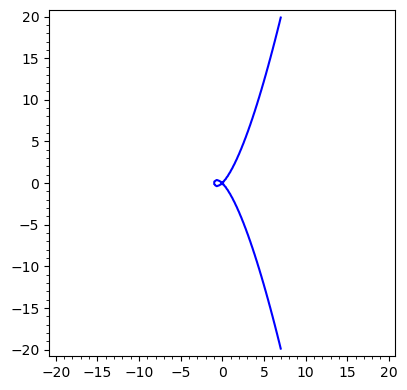

In [79]:
#Cubique de Weierstrass
p = lambda x, y:y^2 - x^3 - x^2
trace_courbe(p,20,20)

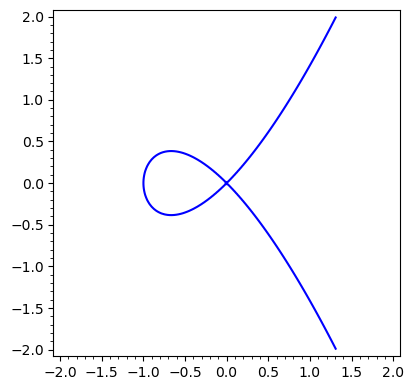

In [80]:
trace_courbe(p,2,2)

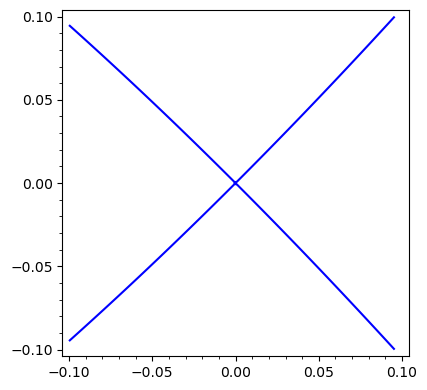

In [81]:
trace_courbe(p,0.1,0.1)

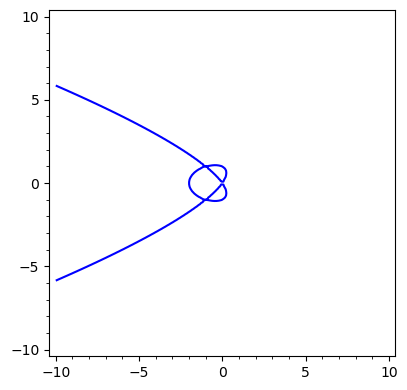

In [82]:
#La quartique Q
q = lambda x, y:y^4 + y^2*(x-1)+x^2*(x+2)
trace_courbe(q,10,10)

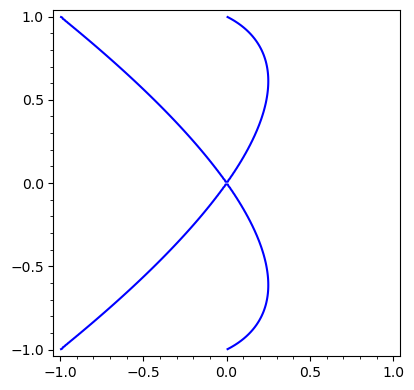

In [83]:
trace_courbe(q,1,1)

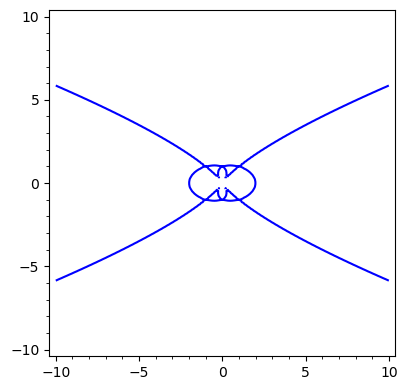

In [84]:
#Le cas réductible
q2 = lambda x, y:(y^4 + y^2*(x-1)+x^2*(x+2))*(y^4 + y^2*(-x-1)+x^2*(-x+2))
trace_courbe(q2,10,10)

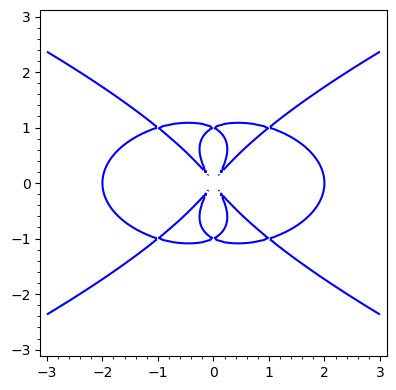

In [85]:
trace_courbe(q2,3,3)

In [86]:
def trace_courbe_implicite(f,a,b):
    '''
    Entrées :
    f : courbe définie paramétriquement par f
    a : demi-taille de la fenêtre sur l'axe des abscisses
    b : demi-taille de la fenêtre sur l'axe des ordonnées
    Sortie :
    Tracé de la courbe {f(t), t parcourant [a, b]}
    '''
    t = var('t')
    return parametric_plot(f(t), (t,a,b))

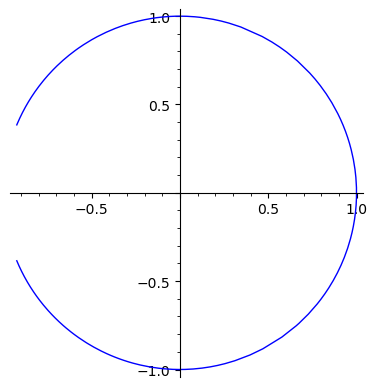

In [87]:
#Cercle (implicite)
C2 = lambda t:((1-t^2)/(1+t^2),(2*t/(1+t^2)))
trace_courbe_implicite(C2,-5,5)

In [88]:
#Pour se garantir de l'aspect affine par morceaux, augmenter le paramètre plot points (plot_points=1000)

## Le cas de la quartique q : éq. cartésienne vers éq. paramétrique

### Étape 1 : tangentes et détermination de points singuliers

In [89]:
F = q

In [90]:
dFx = y^2 + 3*x^2 + 4*x
dFy = 4*y^3 + 2*y*(x-1)
dFx, dFy

(3*x^2 + y^2 + 4*x, 4*y^3 + 2*(x - 1)*y)

In [91]:
dFx.parent()

Symbolic Ring

In [92]:
R.<X,Y> = QQ[]
P = Y^4 + Y^2*(X-1)+X^2*(X+2)

In [93]:
dPx = P.derivative(X)
dPy = P.derivative(Y)
dPx, dPy

(3*X^2 + Y^2 + 4*X, 4*Y^3 + 2*X*Y - 2*Y)

In [94]:
dPx.parent()

Multivariate Polynomial Ring in X, Y over Rational Field

In [95]:
bool(dFx == dPx)

False

In [96]:
G = lambda x, y:P(x,y)
G(0,0)

0

In [97]:
def trace_tangente(f,a,b,x0,y0):
    '''
    Entrées :
    f : courbe définie implicitement par f SOUS LA FORME D'UN POLYNÔME
    a : demi-taille de la fenêtre sur l'axe des abscisses
    b : demi-taille de la fenêtre sur l'axe des ordonnées
    (x_0, y_0) : point du plan, non singulier pour f
    Sortie :
    Tracé de la courbe f(x,y) = 0 sur la fenêtre [-a, a] x [-b, b] ainsi que de sa tangente en (x_0, y_0)
    '''
    x, y = var('x, y')
    dfx = f.derivative(X)
    dfy = f.derivative(Y)
    h = lambda x, y:dfx(x0,y0)*(x-x0) + dfy(x0,y0)*(y - y0)
    g = lambda x, y:f(x,y)
    return implicit_plot(g,(x,-a,a),(y,-b,b),color='blue') + implicit_plot(h,(x,-a,a),(y,-b,b),color='red')

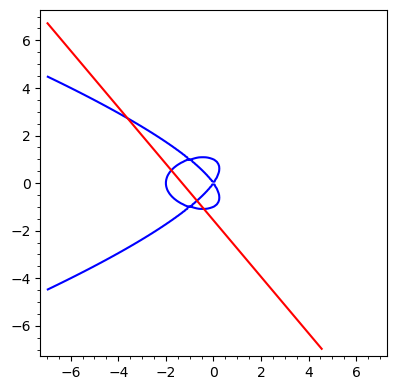

In [98]:
trace_tangente(P,7,7,-3,2)

In [99]:
sol = solve(P(x,y) == 0, y); sol

[y == -sqrt(1/2*x*sqrt(-4*x + 1) - 1/2*x + 1/2*sqrt(-4*x + 1) + 1/2), y == sqrt(1/2*x*sqrt(-4*x + 1) - 1/2*x + 1/2*sqrt(-4*x + 1) + 1/2), y == -sqrt(-1/2*x*sqrt(-4*x + 1) - 1/2*x - 1/2*sqrt(-4*x + 1) + 1/2), y == sqrt(-1/2*x*sqrt(-4*x + 1) - 1/2*x - 1/2*sqrt(-4*x + 1) + 1/2)]

In [100]:
y0 = sol[2].rhs().subs(x=-3).n(); y0

-2.36760454372431

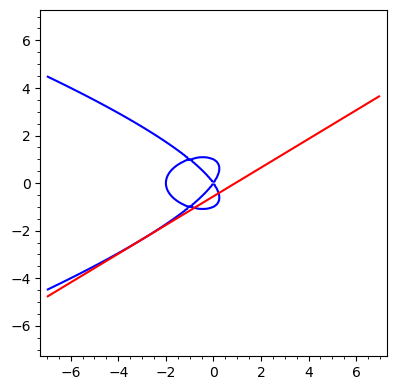

In [102]:
trace_tangente(P,7,7,-3,y0)

In [103]:
@interact
def s(x0=slider(default=-3,vmin=-6.5,vmax=0)):
    return trace_tangente(P,7,5,x0,sol[2].rhs().subs(x=x0).n())

Interactive function <function s at 0x6ffd3ec385f0> with 1 widget
  x0: TransformFloatSlider(value=-3.0, descr…

In [104]:
S1 = P.sylvester_matrix(dPx,Y); S1

[          1           0       X - 1           0 X^3 + 2*X^2           0]
[          0           1           0       X - 1           0 X^3 + 2*X^2]
[          1           0 3*X^2 + 4*X           0           0           0]
[          0           1           0 3*X^2 + 4*X           0           0]
[          0           0           1           0 3*X^2 + 4*X           0]
[          0           0           0           1           0 3*X^2 + 4*X]

In [105]:
R1 = P.resultant(dPx,Y); R1

81*X^8 + 396*X^7 + 790*X^6 + 820*X^5 + 465*X^4 + 136*X^3 + 16*X^2

In [106]:
R1.parent()

Multivariate Polynomial Ring in X, Y over Rational Field

In [107]:
R1X = R1.specialization({Y:0})
R1X.parent()

Univariate Polynomial Ring in X over Rational Field

In [108]:
S2 = P.sylvester_matrix(dPy,X); S2

[          1           2         Y^2   Y^4 - Y^2]
[        2*Y 4*Y^3 - 2*Y           0           0]
[          0         2*Y 4*Y^3 - 2*Y           0]
[          0           0         2*Y 4*Y^3 - 2*Y]

In [109]:
R2Y = P.resultant(dPy,X).specialization({X:0}); R2Y

64*Y^9 - 152*Y^7 + 112*Y^5 - 24*Y^3

In [110]:
R1X.roots() 

[(0, 2), (-4/9, 2), (-1, 4)]

In [111]:
R2Y.roots()

[(1, 2), (-1, 2), (0, 3)]

In [112]:
rac1 = [r[0] for r in R1X.roots()]
rac2 = [r[0] for r in R2Y.roots()]
#Candidats aux points singuliers
rac = [(r,s) for r in rac1 for s in rac2]; rac

[(0, 1),
 (0, -1),
 (0, 0),
 (-4/9, 1),
 (-4/9, -1),
 (-4/9, 0),
 (-1, 1),
 (-1, -1),
 (-1, 0)]

In [113]:
#Remontée de racines
def singulier():
    S=[]
    for r in rac:
        if P(r) == 0 and dPx(r) == 0 and dPy(r) == 0:
            S+=[r]
    return S
S = singulier(); S

[(0, 0), (-1, 1), (-1, -1)]

### Étape 2 : le faisceau de coniques

In [114]:
sol[0].rhs().subs(x=-2)

0

In [115]:
Q = (-2,0)

In [116]:
A=X^2; B=X*Y; C=Y^2; D=X; E=Y; F=X^0
A.parent()

Multivariate Polynomial Ring in X, Y over Rational Field

In [117]:
def matrice_faisceau(S,Q):
    '''
    Entrées :
    S : points singuliers d'une courbe C
    Q : un point non singulier de C
    Sortie :
    Paramétrisation des coniques passant par S et Q
    '''
    A=X^2; B=X*Y; C=Y^2; D=X; E=Y; F=X^0
    mon = [A,B,C,D,E,F]
    M = []
    for s in S:
        L=[]
        for P in mon:
            L+=[P(s)]
        M+=[L]
    L=[]
    for P in mon:
        L+=[P(Q)]
    M+=[L]
    return Matrix(M)

In [118]:
M=matrice_faisceau(S,Q); M

[ 0  0  0  0  0  1]
[ 1 -1  1 -1  1  1]
[ 1  1  1 -1 -1  1]
[ 4  0  0 -2  0  1]

In [119]:
b = [0 for i in S]+[0]; b

[0, 0, 0, 0]

In [120]:
M.right_kernel(b)

Vector space of degree 6 and dimension 2 over Rational Field
Basis matrix:
[1 0 1 2 0 0]
[0 1 0 0 1 0]

In [121]:
V.<t> = QQ[]
U.<X,Y> = V[]
C = X^2 + t*X*Y + Y^2 + 2*X + t*Y
C.parent()

Multivariate Polynomial Ring in X, Y over Univariate Polynomial Ring in t over Rational Field

### Étape 3 : obtention du paramétrage par identification d'un facteur

In [122]:
P = Y^4 + Y^2*(X-1)+X^2*(X+2) + 0*t
P.parent()

Multivariate Polynomial Ring in X, Y over Univariate Polynomial Ring in t over Rational Field

In [123]:
P.sylvester_matrix(C,X)

[        1         2       Y^2 Y^4 - Y^2         0]
[        0         1         2       Y^2 Y^4 - Y^2]
[        1   t*Y + 2 Y^2 + t*Y         0         0]
[        0         1   t*Y + 2 Y^2 + t*Y         0]
[        0         0         1   t*Y + 2 Y^2 + t*Y]

In [124]:
RX = P.resultant(C,X); RX

Y^8 + (-t^3 + 2*t)*Y^7 + (-2)*Y^6 + (2*t^3 - 4*t)*Y^5 + Y^4 + (-t^3 + 2*t)*Y^3

In [125]:
RX.factor()

(Y - t^3 + 2*t) * (Y - 1)^2 * (Y + 1)^2 * Y^3

In [126]:
P.sylvester_matrix(C,Y)

[          1           0       X - 1           0 X^3 + 2*X^2           0]
[          0           1           0       X - 1           0 X^3 + 2*X^2]
[          1     t*X + t   X^2 + 2*X           0           0           0]
[          0           1     t*X + t   X^2 + 2*X           0           0]
[          0           0           1     t*X + t   X^2 + 2*X           0]
[          0           0           0           1     t*X + t   X^2 + 2*X]

In [127]:
RY = P.resultant(C,Y); RY

X^8 + (t^4 - 3*t^2 + 8)*X^7 + (6*t^4 - 18*t^2 + 26)*X^6 + (14*t^4 - 42*t^2 + 44)*X^5 + (16*t^4 - 48*t^2 + 41)*X^4 + (9*t^4 - 27*t^2 + 20)*X^3 + (2*t^4 - 6*t^2 + 4)*X^2

In [128]:
factor(RY)

(X + 2) * (X + t^4 - 3*t^2 + 2) * X^2 * (X + 1)^4

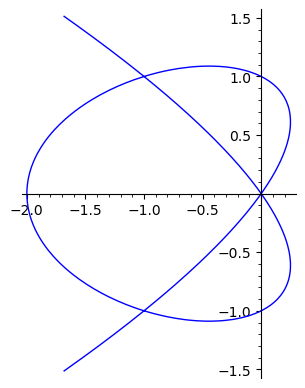

In [129]:
QC = lambda t:( -(t^2-1)*(t^2-2) , t*(t^2-2) )
trace_courbe_implicite(QC,-1.7,1.7)

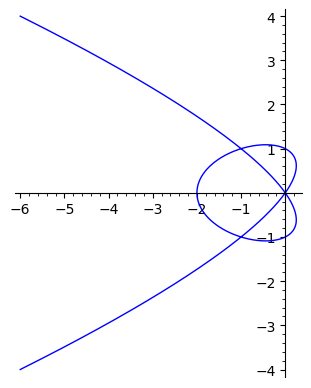

In [130]:
#L'absence du point Q est indétectable.
trace_courbe_implicite(QC,-2,2)

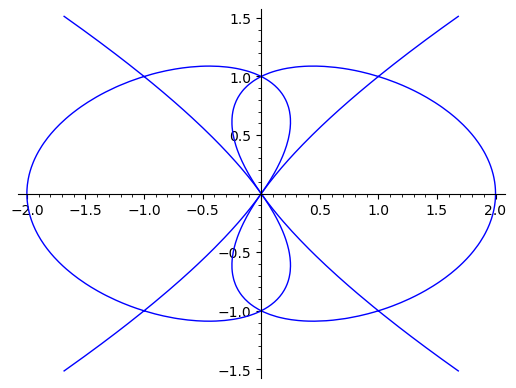

In [131]:
QCM = lambda t:( (t^2-1)*(t^2-2) , t*(t^2-2) )
trace_courbe_implicite(QC,-1.7,1.7) + trace_courbe_implicite(QCM,-1.7,1.7)

## Le cas de la quartique q : éq. paramétrique vers éq. cartésienne

In [132]:
#Échauffement avec le cercle :
R.<X,Y,t> = QQ[]
A = 1-t^2; B = 1 + t^2; C = 2*t; D = B
P = B*X - A; Q = D*Y - C
P.resultant(Q,t)

4*X^2 + 4*Y^2 - 4

In [133]:
def PversC(A,B,C,D):
    R.<X,Y,t> = QQ[]
    P = B*X - A; Q = D*Y - C
    return P.resultant(Q,t)

In [134]:
PversC(-(t^2-1)*(t^2-2),1,t*(t^2-2),1)

Y^4 + X^3 + X*Y^2 + 2*X^2 - Y^2

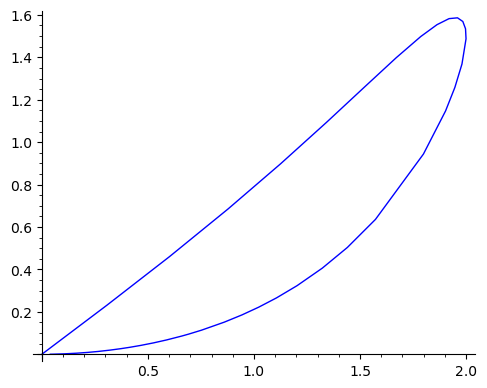

In [135]:
C = lambda t:(4*t/(1+t^2),3*t/(1+t^3))
trace_courbe_implicite(C,0,100)

In [136]:
PversC(4*t,1+t^2,3*t,1+t^3)

9*X^3 + 2*(X^3 - 6*X^2 + 32)*Y^2 + 6*(X^3 - 2*X^2 - 8*X)*Y